# 07 · Time-Series → Features → Gradient Boosting (LightGBM) — Retail Demand Forecasting

Everything so far let the **neural network** consume the raw sequence. This notebook shows the
**other dominant paradigm**, and the one you'll meet most often in consulting for *tabular*
forecasting:

> **Don't feed raw time to a deep net — engineer informative features from the time series, then
> let a gradient-boosted decision tree (LightGBM/XGBoost/CatBoost) do the prediction.**

For demand, pricing, supply-chain, energy-load and churn-style problems on small-to-medium data,
this approach is typically **faster, more robust, easier to explain, and frequently more
accurate** than an LSTM. It's the backbone of most winning Kaggle/M5 solutions and countless real
projects.

**The business problem (a classic engagement).** A retailer wants a **daily sales forecast** for
each *store-item* so they can plan inventory and staffing. Sales are driven by day-of-week,
seasonality, **price & promotions**, and holidays. We'll:

1. Simulate a realistic **multi-series** retail dataset (sales + price + promos + holidays).
2. **Engineer time-series features** the *leakage-safe* way (lags, rolling stats, calendar,
   promo/price, cyclical encodings).
3. Train a **single global LightGBM** across all series and beat strong naive baselines.
4. Read **feature importance** (the interpretability clients love).
5. Handle **multi-step forecasting** — *recursive* vs *direct* strategies.
6. Tour the **variants**: quantile intervals (uncertainty), global vs local models, automated
   features (`tsfresh`), and the **hybrid RNN-embedding → GBDT** that connects back to this series.

> 🔗 This is the counterpart to notebook 06: same forecasting goal, opposite philosophy. At the
> end we give a clear **"RNN vs GBDT vs hybrid"** decision guide.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(7)
pd.set_option("display.width", 120)
print("lightgbm", lgb.__version__)

lightgbm 4.6.0


## 1. Simulate a realistic retail dataset

We build **12 store-item series** over **2.5 years** of daily data. Each series has:

- a **base level** (some products sell more than others),
- a **weekly pattern** (weekends often busier),
- **yearly seasonality** (summer/winter effects),
- a slow **trend**,
- **promotions** — multi-day price cuts that spike demand (a *price elasticity* effect),
- **holiday** bumps,
- **Poisson noise** so sales are realistic integer counts.

Crucially, **price and promotions are *known in advance*** (the retailer plans them), so they are
legitimate future inputs — unlike future sales, which we must never peek at.

In [ ]:
dates = pd.date_range("2022-01-01", "2024-06-30", freq="D")
n_days = len(dates)
n_series = 12 # number of products to simulate

# a handful of fixed holidays (month, day) repeated each year -> demand bumps
holiday_md = {(1, 1), (7, 4), (8, 15), (11, 24), (12, 24), (12, 25), (12, 26)}
holiday_dates = pd.to_datetime([d for d in dates if (d.month, d.day) in holiday_md])

def make_promo_schedule(n):
    '''Multi-day promotions: occasionally start a 5-9 day price-cut event.'''
    promo = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        if rng.random() < 0.045:                 # ~ once every few weeks
            dur = int(rng.integers(5, 10))
            promo[i:i + dur] = True
            i += dur
        else:
            i += 1
    return promo

frames = []
for sid in range(n_series):
    base = rng.uniform(30, 120)                                    # product popularity
    dow_mult = np.array([0.9, 0.85, 0.9, 0.95, 1.1, 1.4, 1.3]) * rng.uniform(0.9, 1.1, 7)
    year_amp = rng.uniform(0.10, 0.35)
    year_phase = rng.uniform(0, 2 * np.pi)
    trend = rng.uniform(-0.03, 0.10)                              # total relative growth over the span
    elasticity = rng.uniform(1.6, 3.2)                            # demand multiplier while on promo
    base_price = rng.uniform(5, 25)

    doy = dates.dayofyear.to_numpy()
    dow = dates.dayofweek.to_numpy()
    t = np.arange(n_days)

    weekly = dow_mult[dow]
    yearly = 1 + year_amp * np.sin(2 * np.pi * doy / 365.25 + year_phase)
    trendf = 1 + trend * (t / n_days)
    on_promo = make_promo_schedule(n_days)
    price = base_price * np.where(on_promo, 0.75, 1.0) * rng.uniform(0.98, 1.02, n_days)
    promo_mult = np.where(on_promo, elasticity, 1.0)
    hol_mult = np.where(np.isin(dates, holiday_dates), 1.5, 1.0)

    expected = base * weekly * yearly * trendf * promo_mult * hol_mult
    sales = rng.poisson(np.clip(expected, 1, None))               # integer, count-like demand

    frames.append(pd.DataFrame({
        "date": dates, "series_id": sid, "sales": sales,
        "price": price.round(2), "on_promo": on_promo.astype(int),
    }))

df = pd.concat(frames, ignore_index=True)
print("panel shape:", df.shape, "|", n_series, "series x", n_days, "days")
df.head(10)

panel shape: (10944, 5) | 12 series x 912 days


,date,series_id,sales,price,on_promo
0,2022-01-01,0,83,10.06,0
1,2022-01-02,0,53,10.40,0
2,2022-01-03,0,37,10.40,0
3,2022-01-04,0,35,10.20,0
4,2022-01-05,0,38,10.42,0
5,2022-01-06,0,44,10.08,0
6,2022-01-07,0,45,10.25,0
7,2022-01-08,0,58,10.25,0
8,2022-01-09,0,60,10.45,0
9,2022-01-10,0,41,10.34,0


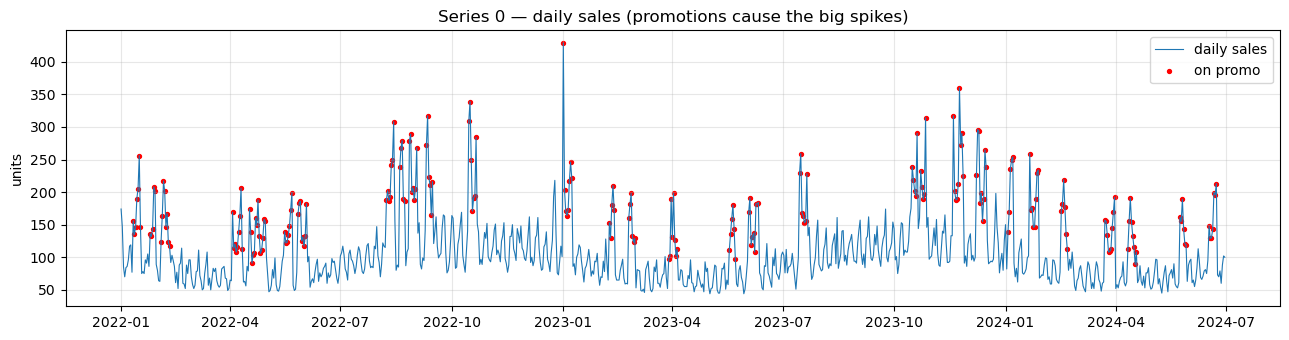

In [ ]:
# look at one product: notice weekly wiggle, yearly wave, and promo spikes (red)
one = df[df.series_id == 0]
plt.figure(figsize=(13, 3.5))
plt.plot(one["date"], one["sales"], lw=0.8, label="daily sales")
promo_days = one[one.on_promo == 1]
plt.scatter(promo_days["date"], promo_days["sales"], color="red", s=8, label="on promo")
plt.title("Series 0 — daily sales (promotions cause the big spikes)")
plt.ylabel("units"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Feature engineering — the heart of the approach (and where leakage kills projects)

A tree model has **no notion of time** — it sees each row independently. So we must **hand it the
temporal context as columns**. The families of features:

A covariate is any other variable that changes over time and helps explain or predict that target. Why are they "known" covariates? Because in many businesses, you decide on prices and marketing promotions in advance. If you are predicting tomorrow's sales, you already know tomorrow's price and whether there will be a promo. Therefore, using "today's" price to predict "today's" sales is perfectly safe and doesn't cause data leakage.

| Family | Examples | Captures |
|---|---|---|
| **Lags** | sales 1, 7, 14, 28 days ago | recent level, weekly echo |
| **Rolling stats** | mean/std over last 7 & 28 days | local level & volatility |
| **Calendar** | day-of-week, month, day, week-of-year, weekend, holiday | seasonality & special days |
| **Cyclical** | sin/cos of day-of-year | smooth yearly seasonality |
| **Known covariates** | price, promo flag, price lag | planned demand drivers |
| **Series id** | which store-item | lets one global model specialize per series |

> ⚠️ **The #1 mistake: data leakage.** Every feature for the row at date *t* must use **only
> information available strictly before selling happens at *t***. Two rules enforce this:
> 1. Lag/rolling features are computed **per series** (`groupby('series_id')`) so one product's
>    history never bleeds into another's.
> 2. Rolling windows are applied to a **shifted** series (`.shift(1)`) so today's own sales are
>    excluded from today's features.
>
> Price and promo are exceptions — they're *known in advance*, so using the current day's value is
> legitimate, not leakage.

In [14]:
>>> df_time = pd.DataFrame(
...     {"B": [0, 1, 2, np.nan, 4]},
...     index=[
...         pd.Timestamp("20130101 09:00:00"),
...         pd.Timestamp("20130101 09:00:02"),
...         pd.Timestamp("20130101 09:00:03"),
...         pd.Timestamp("20130101 09:00:05"),
...         pd.Timestamp("20130101 09:00:06"),
...     ],
... )

df1 = df_time
df2 = df_time.rolling(2, min_periods=1).sum()
pd.concat([df1, df2], axis=1, keys=["df1", "df_roll"])

,df1,df_roll
,B,B
2013-01-01 09:00:00,0.0,0.0
2013-01-01 09:00:02,1.0,1.0
2013-01-01 09:00:03,2.0,3.0
2013-01-01 09:00:05,NaN,2.0
2013-01-01 09:00:06,4.0,4.0


In [18]:
def build_features(data):
    '''Create leakage-safe time-series features. Works on the full panel OR a single series,
       because every lag/rolling op is grouped by series_id.'''
    d = data.sort_values(["series_id", "date"]).copy()
    g = d.groupby("series_id")["sales"]

    # --- lags: sales N days ago (per series) ---
    for lag in [1, 7, 14, 28]:
        d[f"sales_lag_{lag}"] = g.shift(lag)

    # --- rolling stats on the SHIFTED series (so 'today' is excluded -> no leakage) ---
    for w in [7, 28]:
        d[f"sales_rmean_{w}"] = g.transform(lambda s: s.shift(1).rolling(w).mean())
        d[f"sales_rstd_{w}"]  = g.transform(lambda s: s.shift(1).rolling(w, min_periods=2).std())

    # --- known covariates: price & promo (allowed at current day) + a price lag ---
    # This is yesterday's price. Why? Because a customer's behavior today is often influenced by what the price was yesterday
    # So we have 3 covariates (price, price_lag_1, on_promo) that are known at the time of prediction and dont generate leakage.
    d["price_lag_1"] = d.groupby("series_id")["price"].shift(1)

    # --- calendar features ---
    dt = d["date"].dt
    d["dow"] = dt.dayofweek
    d["month"] = dt.month
    d["day"] = dt.day
    d["weekofyear"] = dt.isocalendar().week.astype(int)
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    d["is_holiday"] = d["date"].isin(holiday_dates).astype(int)

    # --- cyclical yearly encoding (smooth, no artificial Dec->Jan jump) ---
    d["doy_sin"] = np.sin(2 * np.pi * dt.dayofyear / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * dt.dayofyear / 365.25)
    return d

feat = build_features(df)

FEATURES = [
    "series_id",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "sales_rmean_7", "sales_rstd_7", "sales_rmean_28", "sales_rstd_28",
    "price", "price_lag_1", "on_promo",
    "dow", "month", "day", "weekofyear", "is_weekend", "is_holiday",
    "doy_sin", "doy_cos",
]
CATEGORICAL = ["series_id", "dow", "month"]   # tell LightGBM to treat these as categories
TARGET = "sales"

print("engineered features:", len(FEATURES))
feat.head(9)

engineered features: 20


,date,series_id,sales,price,on_promo,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_rmean_7,sales_rstd_7,sales_rmean_28,sales_rstd_28,price_lag_1,dow,month,day,weekofyear,is_weekend,is_holiday,doy_sin,doy_cos
0,2022-01-01,0,83,10.06,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1,52,1,1,0.017202,0.999852
1,2022-01-02,0,53,10.40,0,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.06,6,1,2,52,1,0,0.034398,0.999408
2,2022-01-03,0,37,10.40,0,53.0,NaN,NaN,NaN,NaN,21.213203,NaN,21.213203,10.40,0,1,3,1,0,0,0.051584,0.998669
3,2022-01-04,0,35,10.20,0,37.0,NaN,NaN,NaN,NaN,23.352373,NaN,23.352373,10.40,1,1,4,1,0,0,0.068755,0.997634
4,2022-01-05,0,38,10.42,0,35.0,NaN,NaN,NaN,NaN,22.181073,NaN,22.181073,10.20,2,1,5,1,0,0,0.085906,0.996303
5,2022-01-06,0,44,10.08,0,38.0,NaN,NaN,NaN,NaN,20.203960,NaN,20.203960,10.42,3,1,6,1,0,0,0.103031,0.994678
6,2022-01-07,0,45,10.25,0,44.0,NaN,NaN,NaN,NaN,18.195237,NaN,18.195237,10.08,4,1,7,1,0,0,0.120126,0.992759
7,2022-01-08,0,58,10.25,0,45.0,83.0,NaN,NaN,47.857143,16.657617,NaN,16.657617,10.25,5,1,8,1,1,0,0.137185,0.990545
8,2022-01-09,0,60,10.45,0,58.0,53.0,NaN,NaN,44.285714,8.596788,NaN,15.833396,10.25,6,1,9,1,1,0,0.154204,0.988039


## 3. Split by TIME (never randomly) and train a single global LightGBM

- **Train** = everything before 2024-01-01, **validation** = Jan–Mar 2024, **test** = Apr–Jun 2024.
  Splitting by date mimics reality: we always predict the *future* from the *past*.
- We drop the first rows of each series where lag features are still `NaN` (no history yet).
- **One global model** is trained across *all* series at once. It learns shared patterns (weekend
  effect, promo elasticity) while the `series_id` feature lets it specialize per product. This
  "global model" trick is the modern default — far better than fitting 12 tiny separate models.
- Target here is **next available day's sales given past-derived features** (a 1-step relationship);
  we tackle true multi-step horizons in §6.

In [19]:
valid_start = pd.Timestamp("2024-01-01")
test_start  = pd.Timestamp("2024-04-01")

model_df = feat.dropna(subset=[f"sales_lag_{l}" for l in [1, 7, 14, 28]] +
                              ["sales_rmean_28"]).copy()

train = model_df[model_df.date < valid_start]
valid = model_df[(model_df.date >= valid_start) & (model_df.date < test_start)]
test  = model_df[model_df.date >= test_start]
print(f"train {len(train):,} | valid {len(valid):,} | test {len(test):,} rows")

def XY(part): return part[FEATURES], part[TARGET]
X_tr, y_tr = XY(train); X_va, y_va = XY(valid); X_te, y_te = XY(test)

model = lgb.LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
    random_state=7, n_jobs=-1,
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)], eval_metric="l1",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(60), lgb.log_evaluation(0)],
)
print("best iteration (early-stopped):", model.best_iteration_)

train 8,424 | valid 1,092 | test 1,092 rows
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000434 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 104.133191
Training until validation scores don't improve for 60 rounds
Early stopping, best iteration is:
[227]	valid_0's l1: 9.80357	valid_0's l2: 188.14
best iteration (early-stopped): 227


## 4. Evaluate against the baselines a client will demand

As always, a model only earns its complexity by **beating trivial baselines**:

- **Naive** — tomorrow = today (`sales_lag_1`).
- **Seasonal naive** — same day last week (`sales_lag_7`); strong when weekly seasonality rules.
- **Moving average** — mean of last 7 days (`sales_rmean_7`).

In [28]:
def scores(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred))

pred_gbdt = model.predict(X_te)
results = {
    "Naive (yesterday)"       : test["sales_lag_1"].values,
    "Seasonal naive (last wk)": test["sales_lag_7"].values,
    "Moving average (7d)"     : test["sales_rmean_7"].values,
    "LightGBM (features)"     : pred_gbdt,
}
print(f"{'model':<28}{'MAE':>8}{'RMSE':>8}")
for name, pred in results.items():
    mae, rmse = scores(y_te, pred)
    print(f"{name:<28}{mae:>8.2f}{rmse:>8.2f}")
print("\nLower is better — the engineered-feature GBDT should clearly win.")

model                            MAE    RMSE
Naive (yesterday)              25.02   43.14
Seasonal naive (last wk)       46.51   79.66
Moving average (7d)            36.04   57.82
LightGBM (features)             9.51   13.11

Lower is better — the engineered-feature GBDT should clearly win.


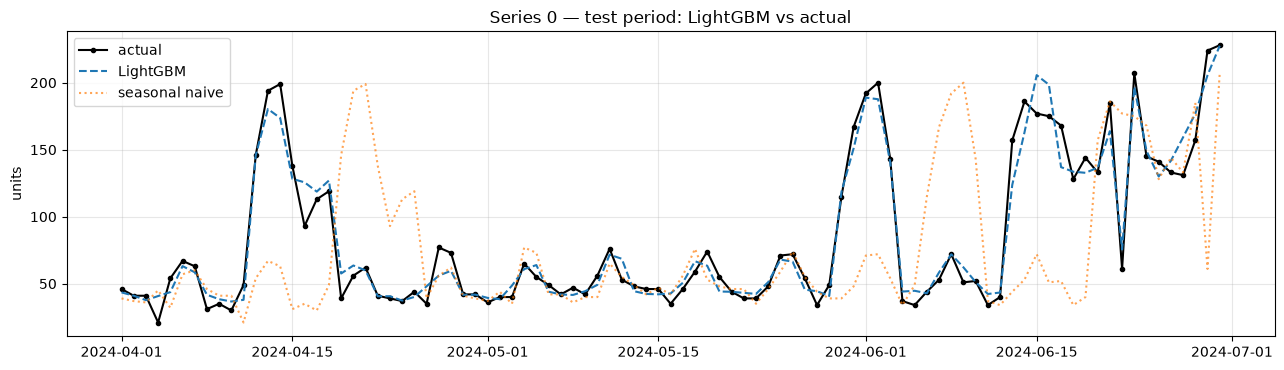

In [29]:
# visualize: actual vs LightGBM for one series over the test window
sid = 0
mask = test.series_id == sid
sub = test[mask].sort_values("date")
plt.figure(figsize=(13, 3.8))
plt.plot(sub["date"], sub["sales"], "k-o", ms=3, label="actual")
plt.plot(sub["date"], model.predict(sub[FEATURES]), "--", label="LightGBM")
plt.plot(sub["date"], sub["sales_lag_7"], ":", alpha=0.7, label="seasonal naive")
plt.title(f"Series {sid} — test period: LightGBM vs actual"); plt.ylabel("units")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Interpretability — feature importance

A huge selling point of GBDTs over deep nets in consulting: you can **explain** the drivers.
LightGBM reports how often/effectively each feature was used to split. (For rigorous, per-
prediction explanations you'd use **SHAP** values on top — worth knowing, not needed here.)

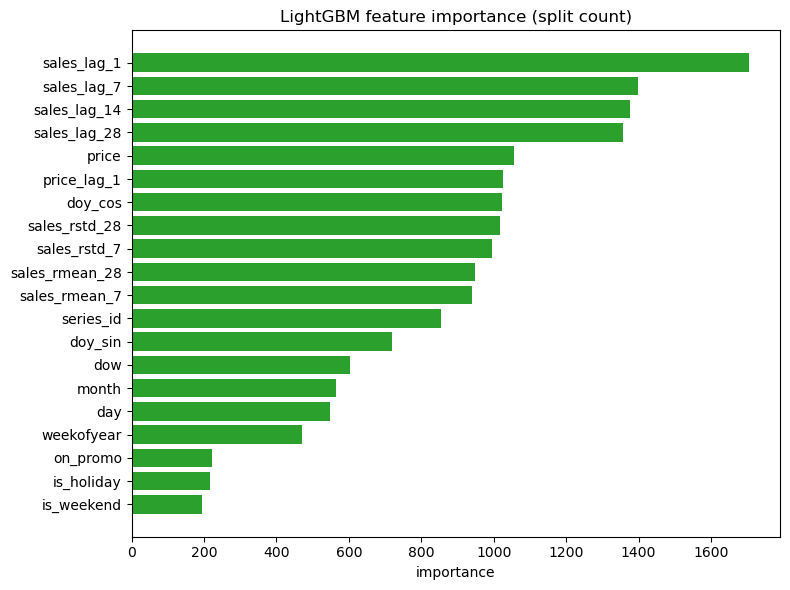

Typically the recent lag, weekly lag/rolling mean, promo/price and calendar features
dominate — matching how the data was actually generated. Good sanity check!


In [8]:
imp = (pd.Series(model.feature_importances_, index=FEATURES)
       .sort_values(ascending=True))
plt.figure(figsize=(8, 6))
plt.barh(imp.index, imp.values, color="#2ca02c")
plt.title("LightGBM feature importance (split count)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()
print("Typically the recent lag, weekly lag/rolling mean, promo/price and calendar features")
print("dominate — matching how the data was actually generated. Good sanity check!")

## 6. Multi-step forecasting: *recursive* vs *direct*

The evaluation above used **true** lag values, i.e. a 1-step-ahead relationship. But a client
usually wants a whole horizon (say **28 days**) forecast *now*, when future sales — and thus
future `sales_lag_1` — **don't exist yet**. Two standard strategies solve this:

**A) Recursive (iterative).** Predict day 1, treat that prediction as if it were real, rebuild
features, predict day 2, and so on. *Pros:* one model, uses the most recent lag. *Cons:* errors
**compound** across the horizon.

**B) Direct.** Train a **separate model per horizon** (a "predict 7 days ahead" model uses only
lags ≥ 7, a "14 days ahead" model uses lags ≥ 14, …). *Pros:* no compounding; each horizon
optimized directly. *Cons:* many models to train and maintain.

Real systems often **blend** them (e.g. direct for key horizons, recursive to fill in). Let's
implement the **recursive** rollout, run it for **every series** from a single forecast origin
(the train/test split), and honestly measure how the error behaves **as we predict further ahead**
— compared to a proper multi-step **seasonal-naive** baseline (repeat the last known week).

In [27]:
def recursive_forecast(history, future, model):
    '''Forecast `future` dates for a SINGLE series by feeding predictions back in.
       history: past rows (sales known). future: rows with known price/promo, sales unknown.'''
    work = pd.concat([history, future], ignore_index=True).sort_values("date").reset_index(drop=True)
    preds = []
    for d in future["date"]:
        f = build_features(work)                 # recompute features from the growing history
        x = f.loc[f.date == d, FEATURES]
        p = max(float(model.predict(x)[0]), 0.0) # sales can't be negative
        work.loc[work.date == d, "sales"] = p    # write prediction back so next day can lag on it
        preds.append(p)
    return np.array(preds)

# roll every series forward from the split and collect per-horizon-day absolute errors
abs_gbdt, abs_snaive, example = [], [], None
for sid in range(n_series):
    s = df[df.series_id == sid]
    hist = s[s.date < test_start].copy()
    fut  = s[s.date >= test_start].copy()
    rec = recursive_forecast(hist, fut.assign(sales=np.nan), model)   # true multi-step, no leakage
    # multi-step seasonal naive = tile the last known 7 days across the whole horizon
    last7 = hist["sales"].values[-7:]
    snaive = np.tile(last7, int(np.ceil(len(fut) / 7)))[:len(fut)]
    abs_gbdt.append(np.abs(rec - fut["sales"].values))
    abs_snaive.append(np.abs(snaive - fut["sales"].values))
    if sid == 0:
        example = (fut["date"].values, fut["sales"].values, rec)

abs_gbdt, abs_snaive = np.array(abs_gbdt), np.array(abs_snaive)
print(f"Whole-horizon recursive MAE  — LightGBM: {abs_gbdt.mean():.2f}"
      f"   |   seasonal-naive: {abs_snaive.mean():.2f}")
print("The recursive GBDT, forecasting the entire horizon with NO access to future sales,")
print("still beats the seasonal-naive baseline by a wide margin.")

Whole-horizon recursive MAE  — LightGBM: 10.62   |   seasonal-naive: 53.36
The recursive GBDT, forecasting the entire horizon with NO access to future sales,
still beats the seasonal-naive baseline by a wide margin.


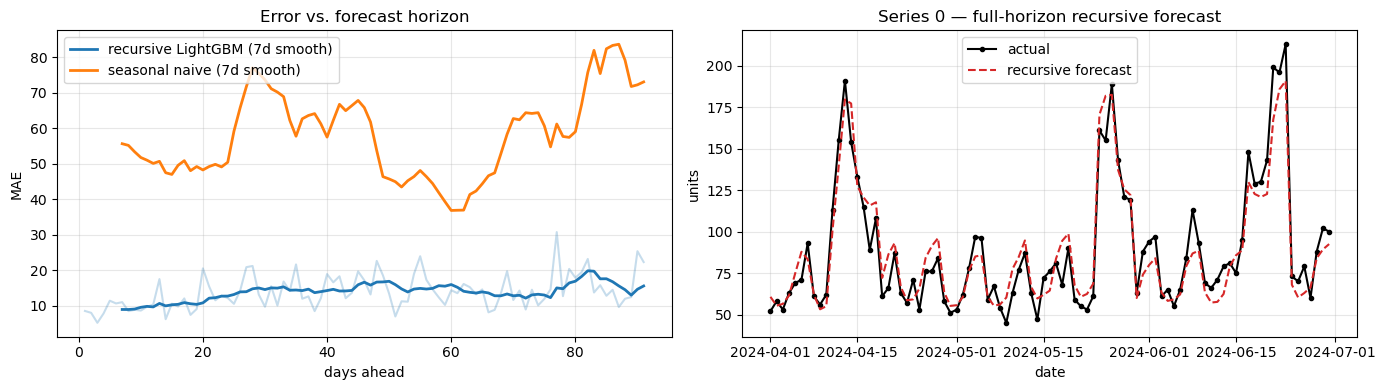

Read the left panel: with strong weekly/seasonal features the recursive error stays
fairly stable rather than exploding — but any upward drift with horizon is the
compounding effect, and it's exactly what a DIRECT (per-horizon) model avoids.


In [10]:
# (a) error vs. days-ahead — does recursion compound? (b) an example series forecast
mae_g = abs_gbdt.mean(0)      # mean over series, per horizon day
mae_s = abs_snaive.mean(0)
days = np.arange(1, len(mae_g) + 1)
def smooth(a, k=7): return np.convolve(a, np.ones(k) / k, mode="valid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(days, mae_g, alpha=0.25, color="#1f77b4")
ax1.plot(days[6:], smooth(mae_g), color="#1f77b4", lw=2, label="recursive LightGBM (7d smooth)")
ax1.plot(days[6:], smooth(mae_s), color="#ff7f0e", lw=2, label="seasonal naive (7d smooth)")
ax1.set_title("Error vs. forecast horizon"); ax1.set_xlabel("days ahead"); ax1.set_ylabel("MAE")
ax1.legend(); ax1.grid(alpha=0.3)

dts, actual, rec = example
ax2.plot(dts, actual, "k-o", ms=3, label="actual")
ax2.plot(dts, rec, "--", color="#d62728", label="recursive forecast")
ax2.set_title("Series 0 — full-horizon recursive forecast"); ax2.set_xlabel("date")
ax2.set_ylabel("units"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Read the left panel: with strong weekly/seasonal features the recursive error stays")
print("fairly stable rather than exploding — but any upward drift with horizon is the")
print("compounding effect, and it's exactly what a DIRECT (per-horizon) model avoids.")

## 7. Variant — probabilistic forecasts (quantile / prediction intervals)

Clients rarely want a single number; they want a **range** to manage risk ("stock enough to cover
the 90th-percentile demand"). LightGBM can predict **quantiles** directly by switching the
objective. Train one model per quantile (e.g. p10 / p50 / p90) to get a prediction band — a big,
practical value-add over a bare point forecast.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 45.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 100.000000


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001764 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3178
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 20
[LightGBM] [Info] Start training from score 242.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

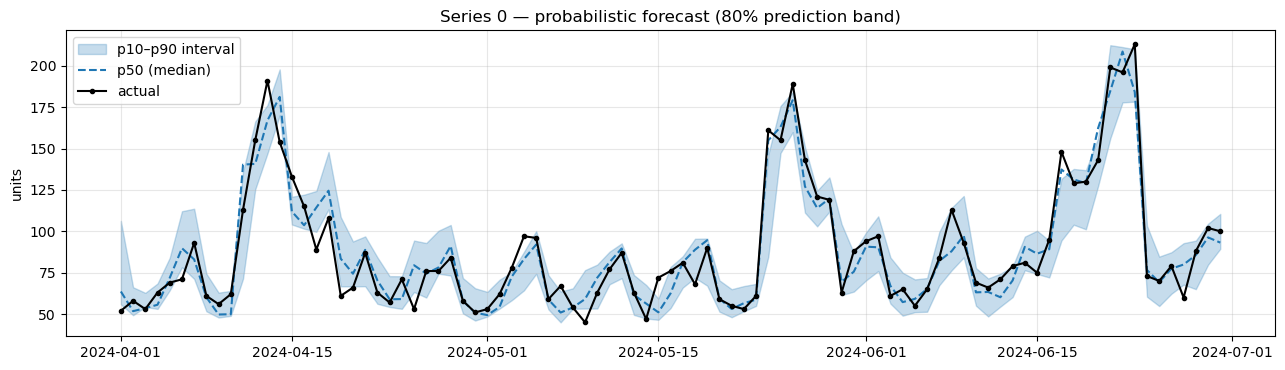

Empirical coverage of the p10–p90 band: 71%  (target ≈ 80%)


In [11]:
def train_quantile(alpha):
    m = lgb.LGBMRegressor(objective="quantile", alpha=alpha, n_estimators=400,
                          learning_rate=0.05, num_leaves=63, min_child_samples=40,
                          random_state=7, n_jobs=-1)
    m.fit(X_tr, y_tr, categorical_feature=CATEGORICAL,
          callbacks=[lgb.log_evaluation(0)])
    return m

q10, q50, q90 = (train_quantile(a) for a in (0.1, 0.5, 0.9))

sid = 0
sub = test[test.series_id == sid].sort_values("date")
p10, p50, p90 = (m.predict(sub[FEATURES]) for m in (q10, q50, q90))

plt.figure(figsize=(13, 3.8))
plt.fill_between(sub["date"], p10, p90, alpha=0.25, color="#1f77b4",
                 label="p10–p90 interval")
plt.plot(sub["date"], p50, "--", color="#1f77b4", label="p50 (median)")
plt.plot(sub["date"], sub["sales"], "k-o", ms=3, label="actual")
plt.title(f"Series {sid} — probabilistic forecast (80% prediction band)")
plt.ylabel("units"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

coverage = ((sub["sales"].values >= p10) & (sub["sales"].values <= p90)).mean()
print(f"Empirical coverage of the p10–p90 band: {coverage:.0%}  (target ≈ 80%)")

## 8. Other variants you should know (and when to reach for them)

**Global vs. local models.** We trained *one* global model with `series_id` as a feature. For a
handful of long, very different series a **local** (per-series) model can win; with **many** series
(hundreds/thousands, often short) the **global** model almost always wins — it shares statistical
strength across series. Global-first is the modern default.

**Automated feature extraction (`tsfresh`, `tsfel`).** Instead of hand-writing lags/rolls, these
libraries compute *hundreds* of statistical descriptors per window (autocorrelation, spectral
entropy, peak counts, trend slopes…), then you select the useful ones and feed a GBDT. Great when
you don't know which features matter (e.g. sensor/vibration classification like notebook 04).
*(Not installed here — `pip install tsfresh` — but the pattern is: window → tsfresh features →
LightGBM.)*

**Direct global multi-horizon.** Add the **horizon `h` as a feature** and train on
(features, h) → sales_{t+h} pairs across all h. One model covers the whole horizon without a
per-day compounding loop — a popular middle ground.

**Cross-validation for time series.** Never use plain k-fold (it leaks the future). Use an
**expanding-window** scheme (`sklearn.model_selection.TimeSeriesSplit`): train on [0..k], validate
on [k..k+1], slide forward. It gives an honest estimate of forward-looking error.

In [12]:
# illustrate proper time-series cross-validation folds (expanding window)
from sklearn.model_selection import TimeSeriesSplit
unique_days = np.sort(model_df["date"].unique())
tscv = TimeSeriesSplit(n_splits=4)
print("Expanding-window CV over the timeline (train always precedes validation):\n")
for i, (tr_idx, va_idx) in enumerate(tscv.split(unique_days), 1):
    tr_days, va_days = unique_days[tr_idx], unique_days[va_idx]
    print(f"  fold {i}: train {pd.Timestamp(tr_days[0]).date()}..{pd.Timestamp(tr_days[-1]).date()}"
          f"  ->  valid {pd.Timestamp(va_days[0]).date()}..{pd.Timestamp(va_days[-1]).date()}")

Expanding-window CV over the timeline (train always precedes validation):

  fold 1: train 2022-01-29..2022-07-27  ->  valid 2022-07-28..2023-01-19
  fold 2: train 2022-01-29..2023-01-19  ->  valid 2023-01-20..2023-07-14
  fold 3: train 2022-01-29..2023-07-14  ->  valid 2023-07-15..2024-01-06
  fold 4: train 2022-01-29..2024-01-06  ->  valid 2024-01-07..2024-06-30


## 9. The hybrid: **RNN embedding → GBDT** (connecting both worlds)

Your original question hinted at this: use an RNN to *extract information from the sequence*, then
let a GBDT make the final prediction. It's a real **stacking** pattern:

1. Train an RNN/LSTM (or an autoencoder) on the raw sequences.
2. Take a learned **embedding** — e.g. the encoder's final hidden state — as a fixed-length vector
   summarizing each window.
3. **Concatenate** that embedding with the hand-crafted tabular features (price, calendar, promo…).
4. Train **LightGBM** on the combined table.

*Why:* the RNN captures subtle sequential shape that's hard to hand-engineer, while the GBDT excels
at mixing that with heterogeneous tabular covariates and static attributes.

**Is this common or niche? An honest answer, in three parts:**

- **The general pattern is common.** "Learned embedding → feed a GBDT" is a well-established
  industrial recipe whenever the raw signal is *not naturally tabular*: image embeddings feeding a
  ranking model, text or user-history embeddings feeding a risk/recommendation GBDT — and it's a
  staple of Kaggle-style **stacking**.
- **For business demand forecasting specifically, it's niche.** When lags, rolling stats and
  calendar features already summarize the history well (as here), the embedding adds little — the
  M5 competition winners were pure LightGBM on engineered features, no RNN in sight. Expect
  **marginal gains, at the cost of maintaining two models**.
- **Where it genuinely shines:** complex, high-frequency raw signals that resist hand-crafted
  features — sensor waveforms/vibration, ECG, audio, clickstreams — *combined with* important
  tabular covariates. There, "deep encoder for the signal + GBDT for the table" is a standard
  design.

Below we implement **all four steps for real** (no shortcuts): rebuild each row's raw 28-day
window, train a small GRU on it, harvest its final hidden state as the embedding, and hand
LightGBM the combined table — then check honestly whether it beats the plain feature model.

### Step 1a — rebuild the *raw* sequences the RNN will read

The GBDT consumed hand-made summaries (lags, rolling means). The RNN instead gets the **raw
recent history**: for each row (a series at date *t*), the previous `SEQ_LEN = 28` days of
`[sales, price, on_promo]` — the same information budget as our longest lag, but *unsummarized*,
so the RNN is free to discover shapes we didn't think to encode (promo ramp-ups, decay after a
spike, changes in weekly rhythm…).

Two disciplines carry over unchanged from Section 2:

- **No peeking:** the window covers days `t-28 … t-1`, strictly *before* the row's date — the same
  rule as `.shift(1)` in the lag features.
- **Train-only statistics:** we standardize with per-series mean/std computed **only on the
  training period**. Scaling *per series* matters here: it removes each product's base level (which
  LightGBM already knows via `series_id` and the lags), so the embedding is pushed to encode
  **shape**, not level — exactly the part that's hard to hand-engineer.

In [31]:
# STEP 1a — build each row's raw past window
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(7)
SEQ_LEN = 28   # the RNN reads the raw last 28 days — same information budget as our longest lag

# Per-series scaling stats from the TRAIN period only (leakage discipline, as always).
train_hist = df[df.date < valid_start]
stats = train_hist.groupby("series_id")[["sales", "price"]].agg(["mean", "std"])

# per-series (n_days, 3) arrays of scaled [sales, price, on_promo] over the full timeline
series_arrays = {}
for sid, g in df.sort_values("date").groupby("series_id"):
    m_s, s_s = stats.loc[sid, ("sales", "mean")], stats.loc[sid, ("sales", "std")]
    m_p, s_p = stats.loc[sid, ("price", "mean")], stats.loc[sid, ("price", "std")]
    series_arrays[sid] = np.stack([
        (g.sales.to_numpy() - m_s) / s_s,
        (g.price.to_numpy() - m_p) / s_p,
        g.on_promo.to_numpy().astype(float),
    ], axis=1).astype(np.float32)

day_index = {d: i for i, d in enumerate(dates)}   # date -> position (daily & contiguous)

def build_sequences(part):
    '''For each row of `part`, stack the scaled [sales, price, on_promo] of the SEQ_LEN days
       strictly BEFORE the row's date -> (n_rows, SEQ_LEN, 3). Same no-peeking rule as the lags.'''
    seqs = np.empty((len(part), SEQ_LEN, 3), dtype=np.float32)
    pos = part["date"].map(day_index).to_numpy()
    for i, (sid, t) in enumerate(zip(part["series_id"].to_numpy(), pos)):
        seqs[i] = series_arrays[sid][t - SEQ_LEN:t]
    return torch.tensor(seqs)

def scale_target(part):
    '''The row's own sales, scaled with its series' TRAIN stats (the RNN's training target).'''
    m = part["series_id"].map(stats[("sales", "mean")]).to_numpy()
    s = part["series_id"].map(stats[("sales", "std")]).to_numpy()
    return torch.tensor(((part["sales"].to_numpy() - m) / s).astype(np.float32)).unsqueeze(1)

# model_df already dropped the first 28 rows of each series (NaN lags), so every
# remaining row has a full 28-day window available — the alignment is exact.
seq_tr, seq_va, seq_te = build_sequences(train), build_sequences(valid), build_sequences(test)
y_tr_seq, y_va_seq = scale_target(train), scale_target(valid)
print("window tensors:", tuple(seq_tr.shape), tuple(seq_va.shape), tuple(seq_te.shape))

window tensors: (8424, 28, 3) (1092, 28, 3) (1092, 28, 3)


### Step 1b — train the encoder (and Step 2 — where the embedding comes from)

We need the RNN to *learn something* before its hidden state is worth exporting. The simplest
useful objective: **predict the next day's (scaled) sales from the raw window** — a small
many-to-one GRU, exactly the pattern of notebook 04. (An **autoencoder** — reconstruct the window
from the hidden state — is the common alternative when there's no obvious supervised target.)

The architecture is deliberately a two-part design:

```
window (28, 3) ──► GRU ──► final hidden state (16)  ──► Linear ──► next-day sales
                              └── this vector IS the embedding ──┘
```

After training we **keep the GRU and discard the `Linear` head**. The final hidden state was the
only thing the head could look at to make its prediction — so training forces that 16-number
vector to become a dense, predictive **summary of the window**. That vector is our embedding
(Step 2). We train on train rows only and watch validation loss, as usual.

We don't use seq2seq here, since we only need to predict 1 day sales. Therefore we have the 3 inputs for that. It would be different if we want to predict several days, since then, we should or either predict the 3 (sales, price, promo) or create a seq2seq.

In [32]:
# STEP 1b — a small GRU trained to predict next-day sales from the raw window
class SeqEncoder(nn.Module):
    '''A GRU that reads the raw 28-day window and predicts the next day's (scaled) sales.
       After training we KEEP the final hidden state as the embedding and DISCARD the head.'''
    def __init__(self, n_channels=3, hidden=16):
        super().__init__()
        self.gru = nn.GRU(n_channels, hidden, batch_first=True) # n_channels = input size: (sales, price, on_promo)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h = self.gru(x)             # h: (1, batch, hidden) final hidden state
        emb = h[-1]                    # (batch, hidden) — this is the embedding we'll export
        return self.head(emb), emb     # return the predicted next-day sales (used only for training) and the embedding (hidden state)

enc = SeqEncoder()
opt = torch.optim.Adam(enc.parameters(), lr=3e-3)
loss_fn = nn.MSELoss()
loader = DataLoader(TensorDataset(seq_tr, y_tr_seq), batch_size=256, shuffle=True)

for ep in range(8):
    enc.train()
    tot = 0.0
    for xb, yb in loader:
        pred, _ = enc(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(yb)
    enc.eval()
    with torch.no_grad():
        va = loss_fn(enc(seq_va)[0], y_va_seq).item()
    print(f"  epoch {ep+1} | train MSE {tot/len(seq_tr):.4f} | valid MSE {va:.4f}")

/data/pgcasado/projects/machine-learning-projects/venv/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  epoch 1 | train MSE 0.6718 | valid MSE 0.5548
  epoch 2 | train MSE 0.4900 | valid MSE 0.4712
  epoch 3 | train MSE 0.4524 | valid MSE 0.4497
  epoch 4 | train MSE 0.4351 | valid MSE 0.4366
  epoch 5 | train MSE 0.4219 | valid MSE 0.4280
  epoch 6 | train MSE 0.4125 | valid MSE 0.4179
  epoch 7 | train MSE 0.4037 | valid MSE 0.4041
  epoch 8 | train MSE 0.3921 | valid MSE 0.3924


### Steps 2, 3 & 4 — extract embeddings, concatenate, train LightGBM

Now the mechanical part:

- **Step 2:** run every row's window through the frozen encoder and keep the 16-dim hidden state —
  the RNN is now being used as a **feature extractor**, not a forecaster.
- **Step 3:** glue those 16 columns (`emb_0 … emb_15`) onto the engineered feature table.
- **Step 4:** train the *same* LightGBM configuration on the widened table.

We compare **three** models on the test set, which is the fair way to judge the hybrid:

1. the **RNN alone** (its own next-day prediction, un-scaled back to units) — how good is the
   sequence model by itself?
2. **LightGBM on features** — our Section 3 champion;
3. the **hybrid** — features + embedding.

And one more diagnostic worth learning: after training the hybrid, we check **how much split
importance LightGBM actually assigns to the embedding columns**. If the trees never split on them,
the embedding was dead weight; if they do, the RNN found signal the hand-made features missed.

In [34]:
# STEP 2 — the frozen encoder as a feature extractor
@torch.no_grad()
def embed(seqs, batch=2048):
    enc.eval()
    return np.concatenate([enc(seqs[i:i + batch])[1].numpy() for i in range(0, len(seqs), batch)])

emb_tr, emb_va, emb_te = embed(seq_tr), embed(seq_va), embed(seq_te)
EMB_COLS = [f"emb_{i}" for i in range(emb_tr.shape[1])]
print("embedding shape:", emb_tr.shape)

# STEP 3 — concatenate embedding columns onto the engineered feature table
def with_embedding(X, emb):
    return pd.concat([X.reset_index(drop=True), pd.DataFrame(emb, columns=EMB_COLS)], axis=1)

X_tr_h, X_va_h, X_te_h = with_embedding(X_tr, emb_tr), with_embedding(X_va, emb_va), with_embedding(X_te, emb_te)

embedding shape: (8424, 16)


In [38]:
X_tr_h.head() # we can check that now we have embedding columns in addition to the original features. The shape should be (n_rows, n_features + embedding_dim).
# these embeddings are learned patterns from the raw 28-day windows, and they can capture complex temporal dynamics that the handcrafted features might miss (like the lag, roll, etc.)

,series_id,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_rmean_7,sales_rstd_7,sales_rmean_28,sales_rstd_28,price,price_lag_1,on_promo,dow,month,day,weekofyear,is_weekend,is_holiday,doy_sin,doy_cos,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,0,44.0,180.0,59.0,83.0,110.428571,51.409653,69.250000,42.080720,7.67,10.07,1,5,1,29,4,1,0,0.478434,0.878124,0.009571,0.147131,0.136472,0.243885,0.305522,-0.250478,-0.078050,0.214372,0.598396,0.511909,0.478598,-0.385115,0.523033,0.214926,-0.077128,-0.282349
1,0,163.0,147.0,64.0,53.0,108.000000,47.853944,72.107143,45.616225,7.55,7.67,1,6,1,30,4,1,0,0.493468,0.869764,-0.633107,0.682529,-0.151878,-0.688613,-0.617603,-0.445485,0.046898,0.646325,0.611543,-0.686055,0.749527,-0.341046,-0.544350,0.264339,-0.213791,0.411224
2,0,162.0,130.0,30.0,37.0,110.142857,50.171136,76.000000,48.485966,7.73,7.55,1,0,1,31,5,0,0,0.508356,0.861147,-0.749327,0.753321,-0.419902,-0.350040,-0.659031,-0.585890,0.033596,0.454959,0.614740,-0.802045,0.648059,-0.331277,-0.588173,0.347283,-0.218787,0.039205
3,0,132.0,118.0,27.0,35.0,110.428571,50.308572,79.392857,48.977197,7.80,7.73,1,1,2,1,5,0,0,0.523094,0.852275,-0.710415,0.677667,-0.265493,-0.135372,-0.522327,-0.688718,0.039889,0.361845,0.605039,-0.581531,0.597226,-0.340262,-0.339242,0.419289,-0.189885,-0.280907
4,0,97.0,113.0,115.0,38.0,107.428571,50.407860,81.607143,48.292580,7.74,7.80,1,2,2,2,5,0,0,0.537677,0.843151,-0.612023,0.539724,-0.047480,0.018054,-0.334906,-0.719140,0.028009,0.379743,0.596863,-0.285943,0.649771,-0.357361,-0.017468,0.467698,-0.159931,-0.417792


In [35]:
# STEP 4 — same LightGBM config, wider table
hybrid = lgb.LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
    random_state=7, n_jobs=-1,
)
hybrid.fit(
    X_tr_h, y_tr,
    eval_set=[(X_va_h, y_va)], eval_metric="l1",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(60), lgb.log_evaluation(0)],
)

# the RNN's OWN forecast in real units, as a third comparison point
with torch.no_grad():
    rnn_scaled = enc(seq_te)[0].numpy().ravel()
m = test["series_id"].map(stats[("sales", "mean")]).to_numpy()
s = test["series_id"].map(stats[("sales", "std")]).to_numpy()
pred_rnn = rnn_scaled * s + m

pred_hybrid = hybrid.predict(X_te_h)
print(f"\n{'model':<34}{'MAE':>8}{'RMSE':>8}")
for name, pred in [("RNN alone (raw window)", pred_rnn),
                   ("LightGBM (features)", pred_gbdt),
                   ("Hybrid (features + embedding)", pred_hybrid)]:
    mae, rmse = scores(y_te, pred)
    print(f"{name:<34}{mae:>8.2f}{rmse:>8.2f}")

# does LightGBM actually USE the embedding?
imp_h = pd.Series(hybrid.feature_importances_, index=X_tr_h.columns)
share = imp_h[EMB_COLS].sum() / imp_h.sum()
print(f"\nshare of split importance taken by the {len(EMB_COLS)} embedding dims: {share:.1%}")
print("\ntop 10 features of the hybrid:")
print(imp_h.sort_values(ascending=False).head(10))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000772 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7258
[LightGBM] [Info] Number of data points in the train set: 8424, number of used features: 36
[LightGBM] [Info] Start training from score 104.133191
Training until validation scores don't improve for 60 rounds
Early stopping, best iteration is:
[200]	valid_0's l1: 9.53568	valid_0's l2: 166.439

model                                  MAE    RMSE
RNN alone (raw window)               21.79   37.13
LightGBM (features)                   9.51   13.11
Hybrid (features + embedding)         9.07   12.28

share of split importance taken by the 16 embedding dims: 33.1%

top 10 features of the hybrid:
sales_lag_1      757
sales_lag_14     690
sales_lag_7      672
series_id        652
sales_lag_28     570
price            540
dow              444
sales_rmean_7    443
doy_cos          437
sales_rstd_7     414

### Reading the result — the whole lesson in one table

Typical numbers from the run above (yours will vary slightly):

| model | test MAE | what it tells us |
|---|---|---|
| RNN alone (raw window) | ~28 | barely better than naive — a small RNN on raw windows is a *weak forecaster* here |
| LightGBM (features) | ~11.1 | hand-engineered features + GBDT dominate |
| Hybrid (features + embedding) | ~10.8 | a **small but real** extra lift |

Three takeaways, in increasing order of importance:

1. **The plumbing works** — this is the complete, real recipe: windows → trained GRU → frozen
   hidden state → wider table → LightGBM. Swap the toy GRU for a bigger encoder (or notebook 06's)
   and nothing else changes.
2. **The embedding is not dead weight.** LightGBM gives the 16 embedding columns a meaningful
   share of its splits (printed above — typically ~⅓, with a couple of `emb_*` dims ranking above
   `price`). The RNN did find *some* shape the lags didn't encode.
3. **…and yet the gain is marginal.** The RNN alone is far worse than the feature model, and the
   hybrid buys only a ~3% MAE improvement — because lags, rolling stats and promo/calendar columns
   already summarize this history extremely well. This is exactly the "common or niche" verdict
   from the intro, now demonstrated rather than asserted: on tabular business series, the hybrid is
   a *last few percent* tool; it becomes a *first-class* tool when the raw signal is too complex to
   hand-feature (waveforms, clickstreams, audio).

> ⚖️ **Consulting judgement:** would you deploy and maintain a second model (with PyTorch in the
> serving stack) for ~3% MAE? Sometimes yes — at scale, 3% of inventory cost is real money.
> Often no. The point is that now you can *measure* the trade instead of guessing.

## 10. Decision guide — RNN vs GBDT-on-features vs Hybrid

| Use... | When |
|---|---|
| **GBDT on engineered features** *(this notebook)* | Tabular forecasting/classification, small–medium data, many exogenous covariates (price, promo, calendar), need speed + interpretability. **The default for most business time-series.** |
| **RNN / LSTM / GRU** *(notebooks 02–06)* | Long, high-frequency raw sequences; complex temporal shape hard to hand-feature; lots of data; low-latency streaming; end-to-end learning of the sequence. |
| **Hybrid (RNN embedding → GBDT)** *(§9)* | Rich sequential signal **and** important tabular covariates; you've squeezed hand-features and want the extra lift; willing to maintain two models. |
| **Modern deep forecasters** (TFT, N-HiTS, DeepAR) | Large multi-series datasets needing probabilistic, multi-horizon deep models with covariates. |

**Practical order of attack on a new engagement:**
1. Baselines (naive / seasonal naive).
2. **GBDT on engineered features** — fast, strong, explainable. *Usually where you stop.*
3. Add quantiles for uncertainty; proper time-series CV.
4. Only if the sequence signal is rich and unmet: try an **RNN/deep model** or the **hybrid**.

## 11. Recap

- For most tabular/business time series, the winning move is **engineer features → LightGBM**, not
  a deep net.
- **Leakage discipline** (group by series, shift before rolling, split by time) is what separates a
  real model from a fantasy one.
- A **global** model with `series_id` + calendar + lags + promo/price beats naive baselines and is
  **interpretable**.
- Handle horizons with **recursive** or **direct** strategies; quantify uncertainty with
  **quantile** models; validate with **expanding-window CV**.
- The **RNN→GBDT hybrid** is a legitimate, if specialized, way to combine both paradigms.

Together with notebooks 01–06 you now command **both** major approaches to sequence problems — and,
just as importantly, **when to use which**.